In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [148]:
#dataset link -> https://www.kaggle.com/datasets/mirichoi0218/insurance

df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [134]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

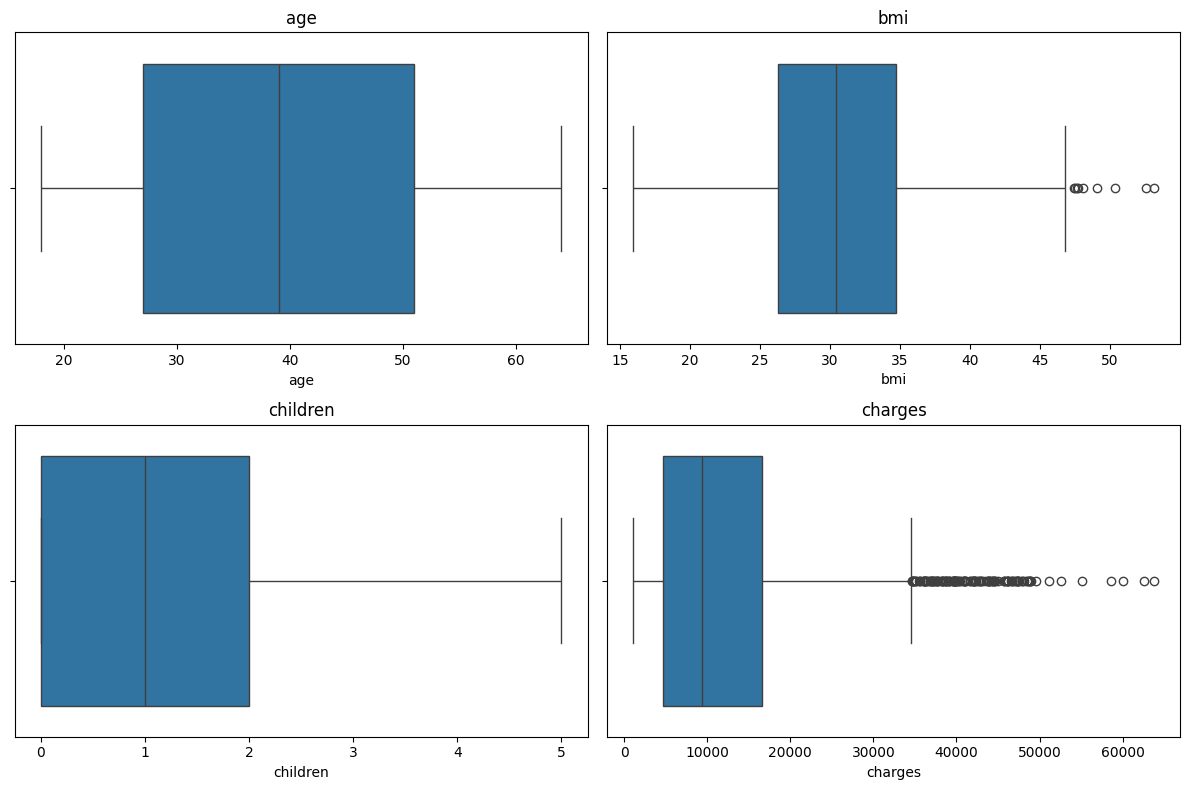

In [135]:
num_col=df.select_dtypes(exclude="object").columns

fig,axes=plt.subplots(2,2,figsize=(12,8))
axes=axes.flatten()

for i,col in enumerate(num_col[:4]):
    sns.boxplot(data=df,x=col,ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [136]:
df_copy = df.copy()  # orijinal df'ye dokunmamak için

def remove_outliers_mad(df, cols, threshold=3.0):
    df_clean = df.copy()
    for col in cols:
        median = df_clean[col].median()
        mad = np.median(np.abs(df_clean[col] - median))
        
        if mad == 0 or np.isnan(mad):
            continue  # mad sıfırsa o kolonu atla (sabit olabilir)
        
        modified_z = 0.6745 * (df_clean[col] - median) / mad
        df_clean = df_clean[np.abs(modified_z) < threshold].copy()
    
    return df_clean
df_copy = remove_outliers_mad(df_copy, ["charges", "bmi"], threshold=3)


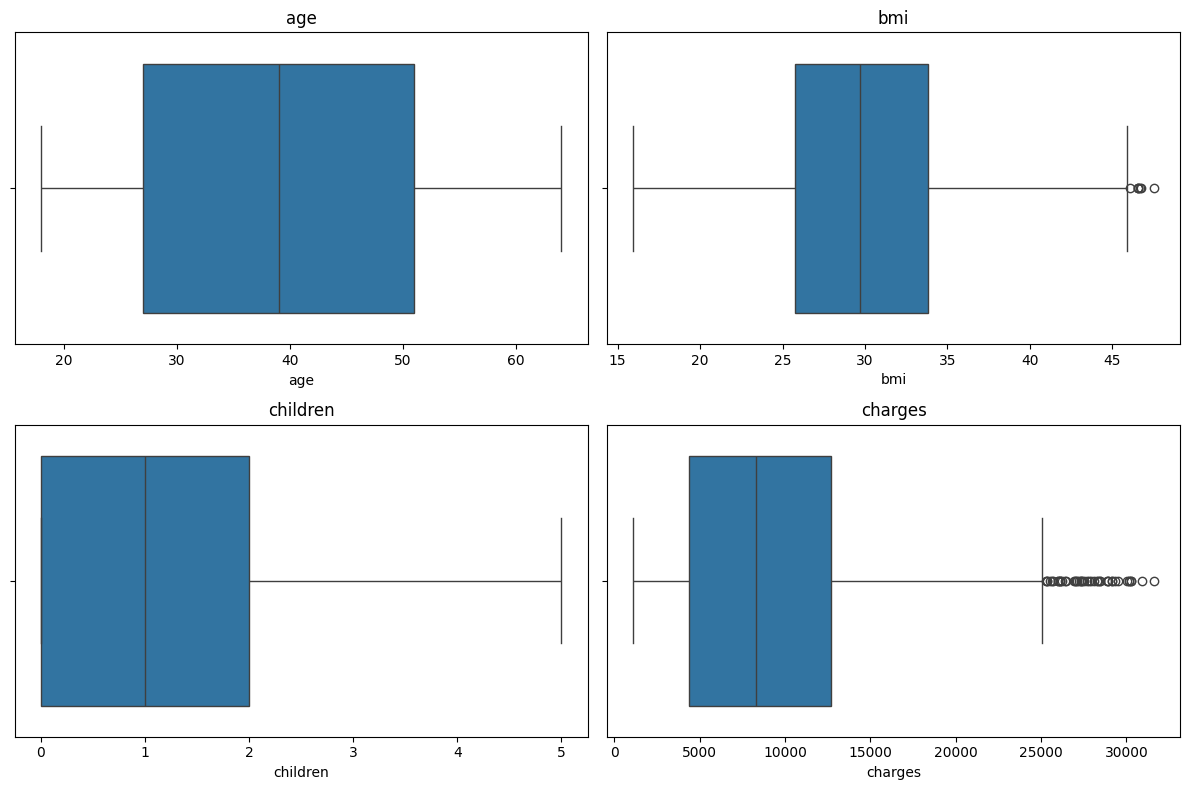

In [137]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
axes=axes.flatten()

for i,col in enumerate(num_col[:4]):
    sns.boxplot(data=df_copy,x=col,ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

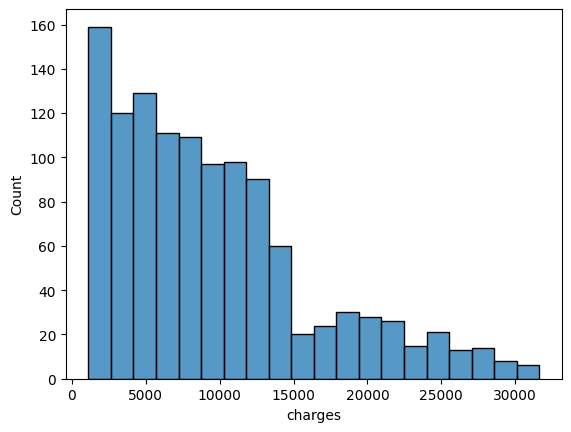

In [138]:
sns.histplot(df_copy["charges"])
plt.show()

In [139]:
df_copy["charges_log"] = np.log1p(df_copy["charges"])

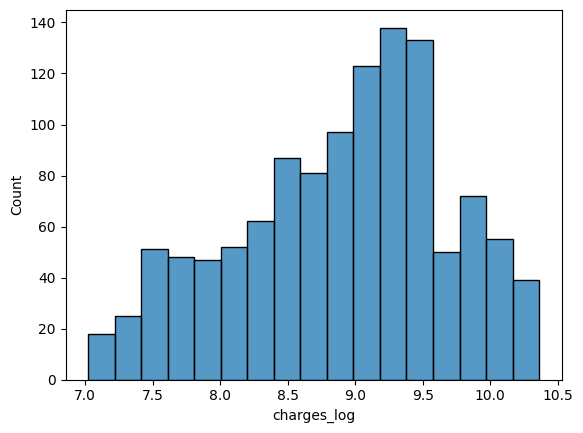

In [140]:
sns.histplot(df_copy["charges_log"])
plt.show()

In [141]:
df_copy.drop("charges",axis=1,inplace=True)

In [142]:
df_copy.head()

,age,sex,bmi,children,smoker,region,charges_log
0,19,female,27.900,0,yes,southwest,9.734236
1,18,male,33.770,1,no,southeast,7.453882
2,28,male,33.000,3,no,southeast,8.400763
3,33,male,22.705,0,no,northwest,9.998137
4,32,male,28.880,0,no,northwest,8.260455


In [143]:
col_cat=df.select_dtypes(include="object")
for col in col_cat:
    print(df[col].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [144]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X = df_copy.drop(columns=["charges_log"])
y = df_copy["charges_log"]


col_num = X.select_dtypes(exclude="object").columns.tolist()
col_cat = X.select_dtypes(include="object").columns.tolist()


pip_num = make_pipeline(
    StandardScaler()
)

pip_cat = make_pipeline(
    OrdinalEncoder(),
    StandardScaler()
)


preprocess = ColumnTransformer(transformers=[
    ("num", pip_num, col_num),
    ("cat", pip_cat, col_cat)
], remainder="drop")


pip_model = make_pipeline(
    preprocess,
    LinearRegression()
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pip_model.fit(X_train, y_train)


,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [145]:
from sklearn.metrics import root_mean_squared_error,mean_squared_error

y_pred=pip_model.predict(X_test)


In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score,root_mean_squared_error

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / np.where(y_test == 0, 1e-9, y_test))).mean() * 100
medae = median_absolute_error(y_test, y_pred)
evs  = explained_variance_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)


print("-" * 45)
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"Adj R²: {adj_r2:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"MedAE : {medae:.4f}")
print(f"EVS   : {evs:.4f}")
print("-" * 45)



---------------------------------------------
MAE   : 0.2239
MSE   : 0.1692
RMSE  : 0.4113
R²    : 0.7144
Adj R²: 0.7069
MAPE  : 2.48%
MedAE : 0.0863
EVS   : 0.7144
---------------------------------------------


In [147]:
from sklearn.linear_model import Ridge, Lasso



col_num = X.select_dtypes(exclude="object").columns
col_cat = X.select_dtypes(include="object").columns

pip_num = make_pipeline(StandardScaler())
pip_cat = make_pipeline(OrdinalEncoder(), StandardScaler())

preprocess = ColumnTransformer([
    ("num", pip_num, col_num),
    ("cat", pip_cat, col_cat)
])

ridge_pipeline = make_pipeline(preprocess, Ridge(alpha=1))
lasso_pipeline = make_pipeline(preprocess, Lasso(alpha=0.1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)

print("Ridge R²:", ridge_pipeline.score(X_test, y_test))
print("Lasso R²:", lasso_pipeline.score(X_test, y_test))


Ridge R²: 0.7143455543110784
Lasso R²: 0.6459469544004706
